<a href="https://colab.research.google.com/github/GabeC117/GabesSoundboard/blob/main/World_Cup_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

df = pd.read_csv('results.csv')
print(df.head())

print(df.shape)
print(df.dtypes)
print(df.describe())



         date home_team away_team  home_score  away_score tournament     city  \
0  1872-11-30  Scotland   England           0           0   Friendly  Glasgow   
1  1873-03-08   England  Scotland           4           2   Friendly   London   
2  1874-03-07  Scotland   England           2           1   Friendly  Glasgow   
3  1875-03-06   England  Scotland           2           2   Friendly   London   
4  1876-03-04  Scotland   England           3           0   Friendly  Glasgow   

    country  neutral  
0  Scotland    False  
1   England    False  
2  Scotland    False  
3   England    False  
4  Scotland    False  
(49071, 9)
date          object
home_team     object
away_team     object
home_score     int64
away_score     int64
tournament    object
city          object
country       object
neutral         bool
dtype: object
         home_score    away_score
count  49071.000000  49071.000000
mean       1.756272      1.182185
std        1.771367      1.401572
min        0.000000      

In [4]:
#date is object we must change
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
print(df.shape)
print(df.dtypes)
print(df.describe())

(49071, 11)
date          datetime64[ns]
home_team             object
away_team             object
home_score             int64
away_score             int64
tournament            object
city                  object
country               object
neutral                 bool
year                   int32
month                  int32
dtype: object
                                date    home_score    away_score  \
count                          49071  49071.000000  49071.000000   
mean   1994-02-21 10:25:13.773919488      1.756272      1.182185   
min              1872-11-30 00:00:00      0.000000      0.000000   
25%              1980-06-15 00:00:00      1.000000      0.000000   
50%              2000-05-28 00:00:00      1.000000      1.000000   
75%              2013-03-22 12:00:00      2.000000      2.000000   
max              2026-01-26 00:00:00     31.000000     21.000000   
std                              NaN      1.771367      1.401572   

               year         month  
count 

In [5]:
#Check for missing values
df.isnull().sum()
print(df.isnull().sum() / len(df) * 100)
df[df['home_score'] > 15]
df[df['away_score'] > 15]

date          0.0
home_team     0.0
away_team     0.0
home_score    0.0
away_score    0.0
tournament    0.0
city          0.0
country       0.0
neutral       0.0
year          0.0
month         0.0
dtype: float64


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,month
237,1908-10-22,France,Denmark,1,17,Olympic Games,London,England,True,1908,10
5900,1963-09-06,Solomon Islands,Tahiti,0,18,South Pacific Games,Suva,Fiji,True,1963,9
8542,1971-09-11,Cook Islands,Papua New Guinea,1,16,South Pacific Games,Papeete,Tahiti,True,1971,9
13804,1983-08-22,Niue,Papua New Guinea,0,19,South Pacific Games,Apia,Western Samoa,True,1983,8
15918,1987-12-15,American Samoa,Papua New Guinea,0,20,South Pacific Games,Nouméa,New Caledonia,True,1987,12
17956,1991-09-15,Guam,New Caledonia,0,18,South Pacific Games,Lae,Papua New Guinea,True,1991,9
20537,1995-08-21,Cook Islands,Solomon Islands,0,16,South Pacific Games,Papeete,Tahiti,True,1995,8
21992,1997-06-02,Maldives,Iran,0,17,FIFA World Cup qualification,Damascus,Syria,True,1997,6
27341,2003-06-30,Sark,Isle of Wight,0,20,Island Games,Saint Martin,Guernsey,True,2003,6
27344,2003-07-01,Micronesia,New Caledonia,0,18,South Pacific Games,Suva,Fiji,True,2003,7


In [6]:
# Two useful subsets to compare
wc_only    = df[df['tournament'] == 'FIFA World Cup']
competitive = df[~df['tournament'].str.contains('Friendly')]
modern      = df[df['year'] >= 2000]  # post-2000 = more relevant

print(f"World Cup only:  {len(wc_only)} matches")
print(f"Competitive:     {len(competitive)} matches")
print(f"Post-2000:       {len(modern)} matches")

World Cup only:  964 matches
Competitive:     30890 matches
Post-2000:       25013 matches


In [9]:
print(df['tournament'].unique())   # see all competition types

wc = df[df['tournament'] == 'FIFA World Cup']
print(wc.shape)
print(wc['year'].value_counts().sort_index())

['Friendly' 'British Home Championship' 'Évence Coppée Trophy'
 'Muratti Vase' 'Copa Lipton' 'Copa Newton' 'Copa Premio Honor Argentino'
 'Olympic Games' 'Copa Premio Honor Uruguayo'
 'Far Eastern Championship Games' 'Copa Roca' 'Copa América'
 'Inter-Allied Games' 'Peace Cup' 'Open International Championship'
 'Soccer Ashes' 'Copa Chevallier Boutell' 'Nordic Championship'
 'Central European International Cup' 'Baltic Cup' 'Balkan Cup'
 'Central American and Caribbean Games' 'FIFA World Cup' 'Copa Rio Branco'
 'FIFA World Cup qualification' 'Bolivarian Games' 'CCCF Championship'
 'NAFC Championship' 'Copa Oswaldo Cruz' 'Asian Games'
 'Pan American Championship' 'Copa del Pacífico' "Copa Bernardo O'Higgins"
 'AFC Asian Cup qualification' 'Atlantic Cup' 'AFC Asian Cup'
 'African Cup of Nations' 'Copa Paz del Chaco' 'Merdeka Tournament'
 'UEFA Euro qualification' 'Southeast Asian Peninsular Games'
 'African Friendship Games' 'UEFA Euro' 'Windward Islands Tournament'
 'African Cup of Natio

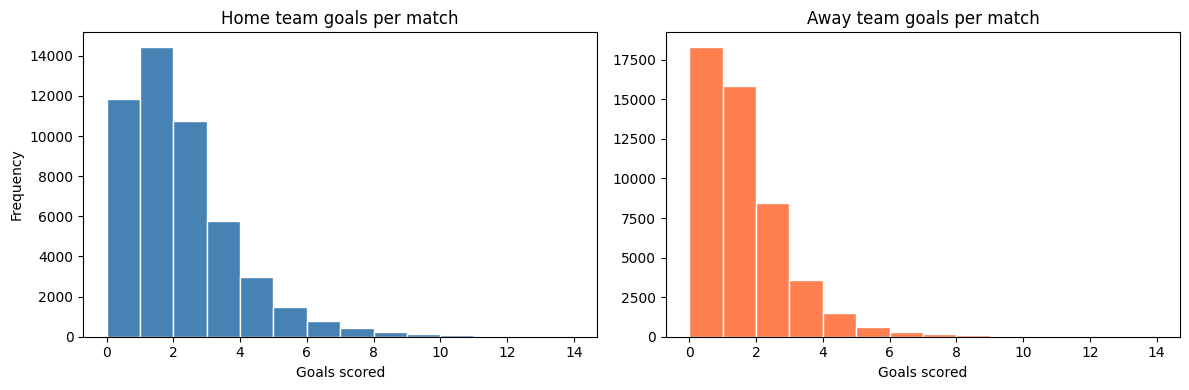

1.76
1.18


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Home goals distribution
axes[0].hist(df['home_score'], bins=range(0, 15),
             edgecolor='white', color='steelblue')
axes[0].set_title('Home team goals per match')
axes[0].set_xlabel('Goals scored')
axes[0].set_ylabel('Frequency')

# Away goals distribution
axes[1].hist(df['away_score'], bins=range(0, 15),
             edgecolor='white', color='coral')
axes[1].set_title('Away team goals per match')
axes[1].set_xlabel('Goals scored')

plt.tight_layout()
plt.savefig('/goal_distributions.png')
plt.show()

# Key stats
print(df['home_score'].mean().round(2))   # ~1.75
print(df['away_score'].mean().round(2))   # ~1.18

In [10]:
# Which teams appear most?
home_counts = df['home_team'].value_counts()
away_counts = df['away_team'].value_counts()
total = (home_counts + away_counts).sort_values(ascending=False)

print(total.head(20))

# World Cup appearances per team
wc_teams = pd.concat([wc['home_team'], wc['away_team']])
print(wc_teams.value_counts().head(20))

# Average goals scored per team (home)
avg_goals = df.groupby('home_team')['home_score'].mean()
print(avg_goals.sort_values(ascending=False).head(10))

Sweden         1097.0
England        1086.0
Argentina      1062.0
Brazil         1055.0
Germany        1027.0
South Korea    1003.0
Hungary        1002.0
Mexico          997.0
Uruguay         966.0
France          931.0
Italy           889.0
Poland          888.0
Switzerland     880.0
Netherlands     875.0
Denmark         870.0
Norway          868.0
Thailand        863.0
Austria         857.0
Belgium         849.0
Scotland        847.0
Name: count, dtype: float64
Brazil           114
Germany          112
Argentina         88
Italy             83
England           74
France            73
Spain             67
Mexico            60
Uruguay           59
Netherlands       55
Belgium           51
Sweden            51
Russia            45
Switzerland       41
South Korea       38
Poland            38
United States     37
Portugal          35
Chile             33
Yugoslavia        33
Name: count, dtype: int64
home_team
Parishes of Jersey    5.500000
Cascadia              5.000000
Hmong         

In [11]:
# Label each match outcome
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 'home_win'
    elif row['home_score'] < row['away_score']:
        return 'away_win'
    else:
        return 'draw'

df['result'] = df.apply(get_result, axis=1)

# Overall split
print(df['result'].value_counts(normalize=True).round(3))

# Compare home vs neutral ground
home_ground = df[df['neutral'] == False]
neutral_ground = df[df['neutral'] == True]

print("\nHome ground:")
print(home_ground['result'].value_counts(normalize=True).round(3))
print("\nNeutral ground:")
print(neutral_ground['result'].value_counts(normalize=True).round(3))

result
home_win    0.490
away_win    0.283
draw        0.227
Name: proportion, dtype: float64

Home ground:
result
home_win    0.507
away_win    0.264
draw        0.228
Name: proportion, dtype: float64

Neutral ground:
result
home_win    0.442
away_win    0.334
draw        0.224
Name: proportion, dtype: float64


Observed home mean: 1.651
Observed away mean: 1.107


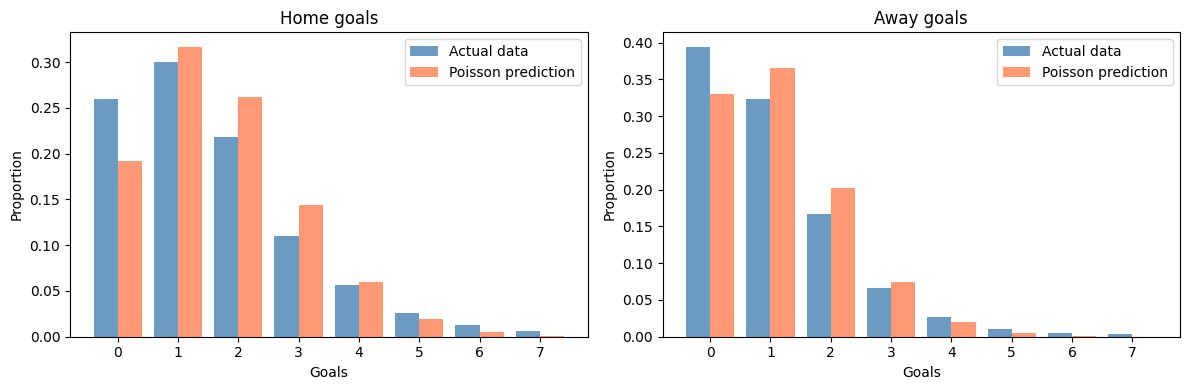

In [15]:
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt

# Your actual data
home_mean = df[df['year'] >= 1990]['home_score'].mean()
away_mean = df[df['year'] >= 1990]['away_score'].mean()

print(f"Observed home mean: {home_mean:.3f}")
print(f"Observed away mean: {away_mean:.3f}")

# Compare actual distribution vs what Poisson predicts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, mean, label in [
    (axes[0], 'home_score', home_mean, 'Home goals'),
    (axes[1], 'away_score', away_mean, 'Away goals')
]:
    actual = df[df['year'] >= 1990][col].value_counts(normalize=True).sort_index()
    poisson_pred = [poisson.pmf(k, mean) for k in range(8)]

    x = range(8)
    ax.bar([i - 0.2 for i in x],
           [actual.get(i, 0) for i in x],
           width=0.4, label='Actual data', color='steelblue', alpha=0.8)
    ax.bar([i + 0.2 for i in x],
           poisson_pred,
           width=0.4, label='Poisson prediction', color='coral', alpha=0.8)
    ax.set_title(label)
    ax.set_xlabel('Goals')
    ax.set_ylabel('Proportion')
    ax.legend()

plt.tight_layout()
plt.savefig('poisson_fit.png')
plt.show()

# Model justification + known limitations

FINDING: Poisson fits the general shape of goal distributions well
 — same right-skewed shape, reasonable fit at 1-3 goals
 — confirms Poisson regression is a principled baseline choice

# LIMITATION: Zero-inflation present in both home and away goals
— actual 0-goal rate exceeds Poisson prediction
— especially for away teams (0.39 actual vs 0.33 predicted)
— root cause: most teams play defensively to start

# IMPLICATION: A basic Poisson model will underestimate 0-0 draws
# and goalless performances from away teams

# POTENTIAL IMPROVEMENT (future work):
Zero-Inflated Poisson (ZIP) model adds a separate parameter
to account for the excess zeros